## Prescriptive Algorithms Assignment 3 Part 1 (Prediction Task)

In [24]:
# Inserting imports for assignment
# Data and visualisation imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling imports
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


### Loading Data

In [25]:
# Load dataset
data = pd.read_csv('DataTrain.csv')
data.head()

,engine_id,cycle,set1,set2,set3,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,...,sensor_val12,sensor_val13,sensor_val14,sensor_val15,sensor_val16,sensor_val17,sensor_val18,sensor_val19,sensor_val20,sensor_val21
0,1,1,100.0,-0.0007,-0.0004,9046.19,521.66,8138.62,1589.70,554.36,...,392,2388.06,1.3,641.82,2388,8.4195,21.61,47.47,14.62,23.4190
1,1,2,100.0,0.0019,-0.0003,9044.07,522.28,8131.49,1591.82,553.75,...,392,2388.04,1.3,642.15,2388,8.4318,21.61,47.49,14.62,23.4236
2,1,3,100.0,-0.0043,0.0003,9052.94,522.42,8133.23,1587.99,554.26,...,390,2388.08,1.3,642.35,2388,8.4178,21.61,47.27,14.62,23.3442
3,1,4,100.0,0.0007,0.0000,9049.48,522.86,8133.83,1582.79,554.45,...,392,2388.11,1.3,642.35,2388,8.3682,21.61,47.13,14.62,23.3739
4,1,5,100.0,-0.0019,-0.0002,9055.15,522.19,8133.80,1582.85,554.00,...,393,2388.06,1.3,642.37,2388,8.4294,21.61,47.28,14.62,23.4044


### Quick data check

In [26]:
data.isnull().sum()

engine_id       0
cycle           0
set1            0
set2            0
set3            0
sensor_val1     0
sensor_val2     0
sensor_val3     0
sensor_val4     0
sensor_val5     0
sensor_val6     0
sensor_val7     0
sensor_val8     0
sensor_val9     0
sensor_val10    0
sensor_val11    0
sensor_val12    0
sensor_val13    0
sensor_val14    0
sensor_val15    0
sensor_val16    0
sensor_val17    0
sensor_val18    0
sensor_val19    0
sensor_val20    0
sensor_val21    0
dtype: int64

In [27]:
data.describe()

,engine_id,cycle,set1,set2,set3,sensor_val1,sensor_val2,sensor_val3,sensor_val4,sensor_val5,...,sensor_val12,sensor_val13,sensor_val14,sensor_val15,sensor_val16,sensor_val17,sensor_val18,sensor_val19,sensor_val20,sensor_val21
count,20631.000000,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,...,20631.000000,20631.000000,20631.0,20631.000000,20631.0,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000
mean,51.506568,108.807862,100.0,-0.000009,0.000002,9065.242941,521.413470,8143.752722,1590.523119,553.367711,...,393.210654,2388.096652,1.3,642.680934,2388.0,8.442146,21.609803,47.541168,1.462000e+01,23.289705
std,29.227633,68.880990,0.0,0.002187,0.000293,22.082880,0.737553,19.076176,6.131150,0.885092,...,1.548763,0.070985,0.0,0.500053,0.0,0.037505,0.001389,0.267087,5.329200e-15,0.108251
min,1.000000,1.000000,100.0,-0.008700,-0.000600,9021.730000,518.690000,8099.940000,1571.040000,549.850000,...,388.000000,2387.900000,1.3,641.210000,2388.0,8.324900,21.600000,46.850000,1.462000e+01,22.894200
25%,26.000000,52.000000,100.0,-0.001500,-0.000200,9053.100000,520.960000,8133.245000,1586.260000,552.810000,...,392.000000,2388.050000,1.3,642.325000,2388.0,8.414900,21.610000,47.350000,1.462000e+01,23.221800
50%,52.000000,104.000000,100.0,0.000000,0.000000,9060.660000,521.480000,8140.540000,1590.100000,553.440000,...,393.000000,2388.090000,1.3,642.640000,2388.0,8.438900,21.610000,47.510000,1.462000e+01,23.297900
75%,77.000000,156.000000,100.0,0.001500,0.000300,9069.420000,521.950000,8148.310000,1594.380000,554.010000,...,394.000000,2388.140000,1.3,643.000000,2388.0,8.465600,21.610000,47.700000,1.462000e+01,23.366800
max,100.000000,362.000000,100.0,0.008700,0.000600,9244.590000,523.380000,8293.720000,1616.910000,556.060000,...,400.000000,2388.560000,1.3,644.530000,2388.0,8.584800,21.610000,48.530000,1.462000e+01,23.618400


### Calculating the RUL (Remaining Useful Lifetime), then dropping 'cycle'

In [28]:
def calculate_RUL(data):
    # Group by 'engine_id' and calculate max 'cycle' for each engine, then compute RUL by substracting current 'cycle' from max 'cycle'
    data['RUL'] = data.groupby('engine_id')['cycle'].transform(max) - data['cycle'] 
    return data

data = calculate_RUL(data)
print(data[data['engine_id'] == 1][['engine_id','cycle', 'RUL']])



     engine_id  cycle  RUL
0            1      1  191
1            1      2  190
2            1      3  189
3            1      4  188
4            1      5  187
..         ...    ...  ...
187          1    188    4
188          1    189    3
189          1    190    2
190          1    191    1
191          1    192    0

[192 rows x 3 columns]


Cycle drop weggehaald

### Dropping features with a low standard deviation, as these features do not influence the prediction 

In [29]:
def drop_low_std_features(data, threshold=0.01, exclude_cols=['engine_id', 'RUL']):
    # Identify columns to check for low std, excluding specified columns
    check_cols = [col for col in data.columns if col not in exclude_cols]
    # Find columns with std below the threshold
    low_std = [col for col in check_cols if data[col].std() < threshold]
    return low_std

# Drop low std features and print them
low_std_features = drop_low_std_features(data)
print(f"Low std features: {low_std_features}")

data_train = data.drop(columns=low_std_features)

Low std features: ['set1', 'set2', 'set3', 'sensor_val7', 'sensor_val8', 'sensor_val11', 'sensor_val14', 'sensor_val16', 'sensor_val18', 'sensor_val20']


### Correlation Matrix of the remaining features

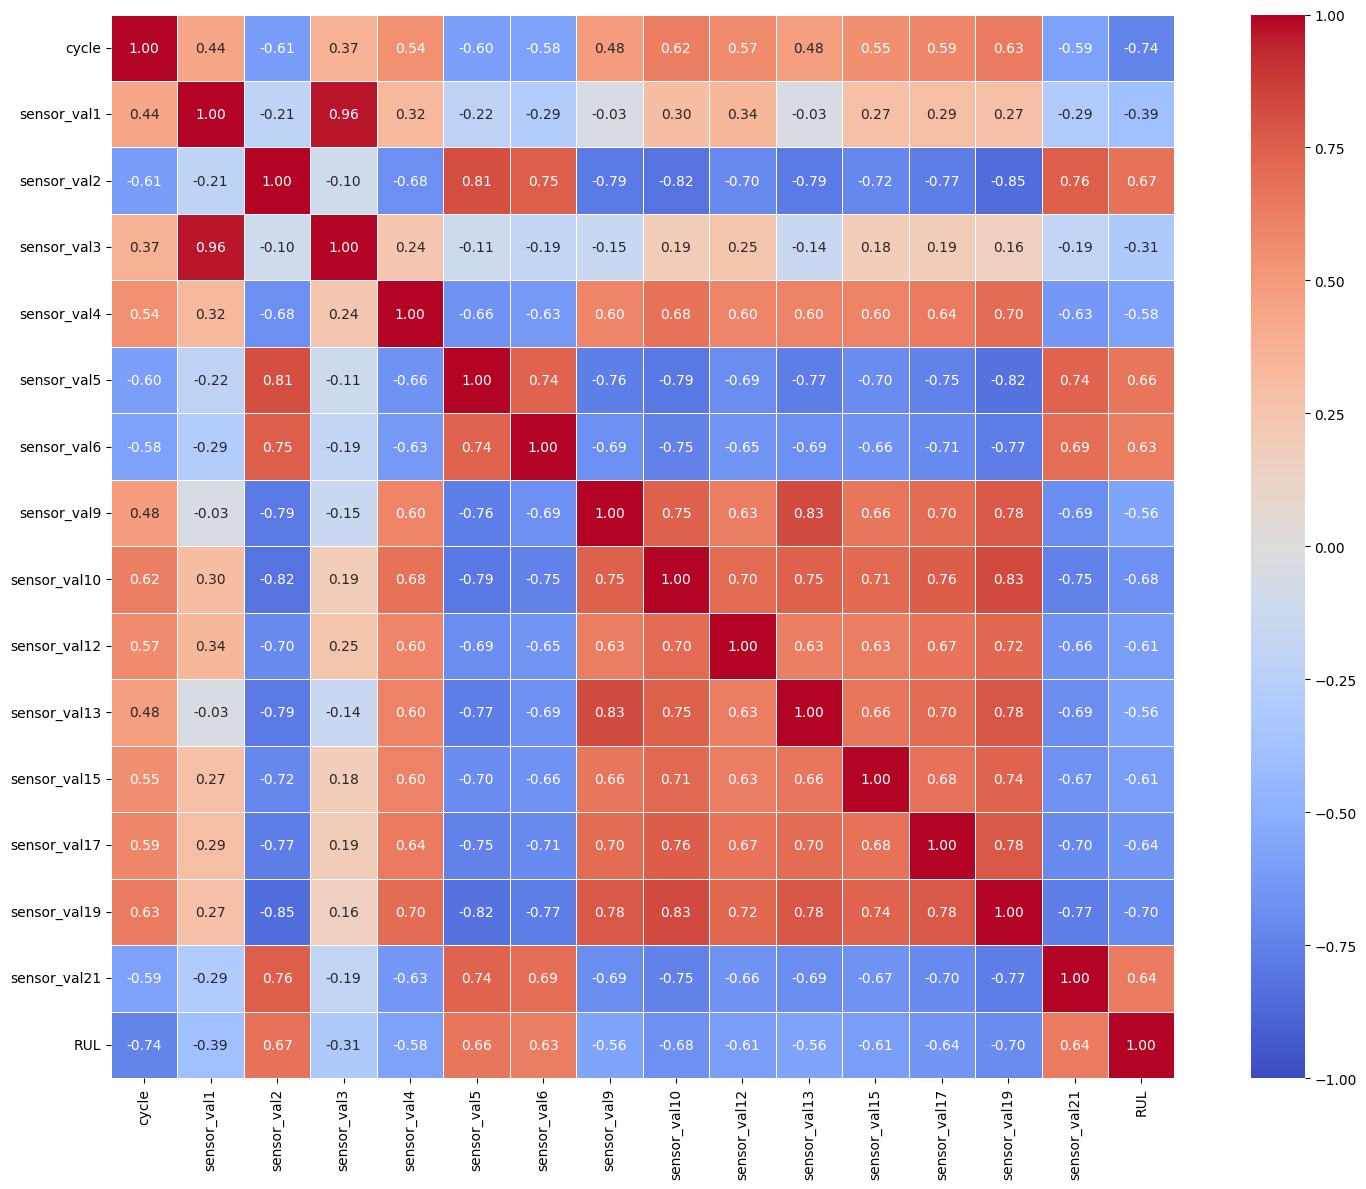

In [30]:
corr_matrix = data_train.drop(columns='engine_id').corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5)

plt.tight_layout()
plt.show()

### Removing sensors with multicollinearity (|r| > 0.9), or low correlation with RUL (|r| < 0.3)

In [31]:
# Only dropping 'sensor_val3' as it has a high correlation with 'sensor_val1' and the weakest correlation with RUL of the two sensors
data_train = data_train.drop(columns=['sensor_val3'])

# No features have correlation with RUL below 0.3, so all are kept

### Figuur beneden gemaakt, vond ik wel grappig, niet perse nodig denk ik

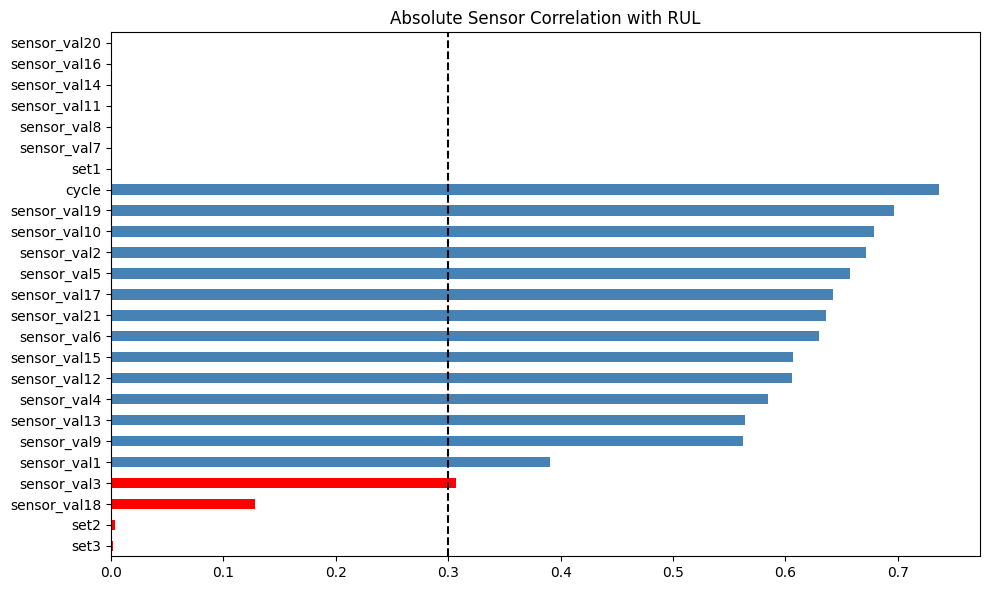

In [32]:
dropped_all = low_std_features + ['sensor_val3']

rul_corr = data.drop(columns='engine_id').corr()['RUL'].drop('RUL')
rul_corr_sorted = rul_corr.abs().sort_values()

colors = ['red' if col in dropped_all else 'steelblue' for col in rul_corr_sorted.index]

plt.figure(figsize=(10, 6))
rul_corr_sorted.plot(kind='barh', color=colors)
plt.axvline(0.3, color='black', linestyle='--', label='threshold = 0.3')
plt.title('Absolute Sensor Correlation with RUL')
plt.tight_layout()
plt.show()

## XGBoost code (gebruik data_train)

In [33]:
data_train.describe()

,engine_id,cycle,sensor_val1,sensor_val2,sensor_val4,sensor_val5,sensor_val6,sensor_val9,sensor_val10,sensor_val12,sensor_val13,sensor_val15,sensor_val17,sensor_val19,sensor_val21,RUL
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,51.506568,108.807862,9065.242941,521.413470,1590.523119,553.367711,38.816271,2388.096152,1408.933782,393.210654,2388.096652,642.680934,8.442146,47.541168,23.289705,107.807862
std,29.227633,68.880990,22.082880,0.737553,6.131150,0.885092,0.180746,0.071919,9.000605,1.548763,0.070985,0.500053,0.037505,0.267087,0.108251,68.880990
min,1.000000,1.000000,9021.730000,518.690000,1571.040000,549.850000,38.140000,2387.880000,1382.250000,388.000000,2387.900000,641.210000,8.324900,46.850000,22.894200,0.000000
25%,26.000000,52.000000,9053.100000,520.960000,1586.260000,552.810000,38.700000,2388.040000,1402.360000,392.000000,2388.050000,642.325000,8.414900,47.350000,23.221800,51.000000
50%,52.000000,104.000000,9060.660000,521.480000,1590.100000,553.440000,38.830000,2388.090000,1408.040000,393.000000,2388.090000,642.640000,8.438900,47.510000,23.297900,103.000000
75%,77.000000,156.000000,9069.420000,521.950000,1594.380000,554.010000,38.950000,2388.140000,1414.555000,394.000000,2388.140000,643.000000,8.465600,47.700000,23.366800,155.000000
max,100.000000,362.000000,9244.590000,523.380000,1616.910000,556.060000,39.430000,2388.560000,1441.490000,400.000000,2388.560000,644.530000,8.584800,48.530000,23.618400,361.000000


## Prepare X and Y for XBoost model

Engine_id and RUL are dropped from X. The RUL needs to be predicted, which is stored in y.

In [34]:
X = data_train.drop(columns=['engine_id', 'RUL'])
y = data_train['RUL']

print("Number of features:", X.shape[1])
print("Number of rows:", X.shape[0])
X.head()

Number of features: 14
Number of rows: 20631


,cycle,sensor_val1,sensor_val2,sensor_val4,sensor_val5,sensor_val6,sensor_val9,sensor_val10,sensor_val12,sensor_val13,sensor_val15,sensor_val17,sensor_val19,sensor_val21
0,1,9046.19,521.66,1589.70,554.36,39.06,2388.02,1400.60,392,2388.06,641.82,8.4195,47.47,23.4190
1,2,9044.07,522.28,1591.82,553.75,39.00,2388.07,1403.14,392,2388.04,642.15,8.4318,47.49,23.4236
2,3,9052.94,522.42,1587.99,554.26,38.95,2388.03,1404.20,390,2388.08,642.35,8.4178,47.27,23.3442
3,4,9049.48,522.86,1582.79,554.45,38.88,2388.08,1401.87,392,2388.11,642.35,8.3682,47.13,23.3739
4,5,9055.15,522.19,1582.85,554.00,38.90,2388.04,1406.22,393,2388.06,642.37,8.4294,47.28,23.4044


## Split the data + Running the model

This is done according to a split of 80-20.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #random state for reproducibility)

Run the XG Boost model on the train data.

In [36]:
xgb_model = XGBRegressor(
    objective='reg:squarederror', # regression
    n_estimators=250, # 250 trees
    max_depth=4,  # maximum depth of tree, a higher value is more likely to overfit
    learning_rate=0.05,
    subsample=0.8, # trained on 80% of observations
    colsample_bytree=0.8, # 80% of features
    random_state=42 # for reproducibility
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

After this, the model is evaluated. This is done with the MAE, MSE, RMSE and R-squared. 

In [37]:
y_pred = xgb_model.predict(X_test)

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = MSE ** 0.5
R2 = r2_score(y_test, y_pred)

print("MAE:", round(MAE, 2))
print("MSE:", round(MSE, 2))
print("RMSE:", round(RMSE, 2))
print("R-squared:", round(R2, 4))

MAE: 25.36
MSE: 1267.73
RMSE: 35.61
R-squared: 0.7225


## 5-fold cross-validation

Below a 5-fold cross-validation is done, which gives the model a better performance.

In [38]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=kfold,
    scoring='neg_mean_absolute_error'
)

cv_mae_scores = -cv_scores

print("CV MAE scores:", ", ".join(f"{score:.2f}" for score in cv_mae_scores))
print(f"Average CV MAE: {cv_mae_scores.mean():.2f}")


CV MAE scores: 25.35, 25.10, 25.52, 24.86, 25.54
Average CV MAE: 25.28


## The most important features
The figure below shows the 12 most important features for the prediction within the model.

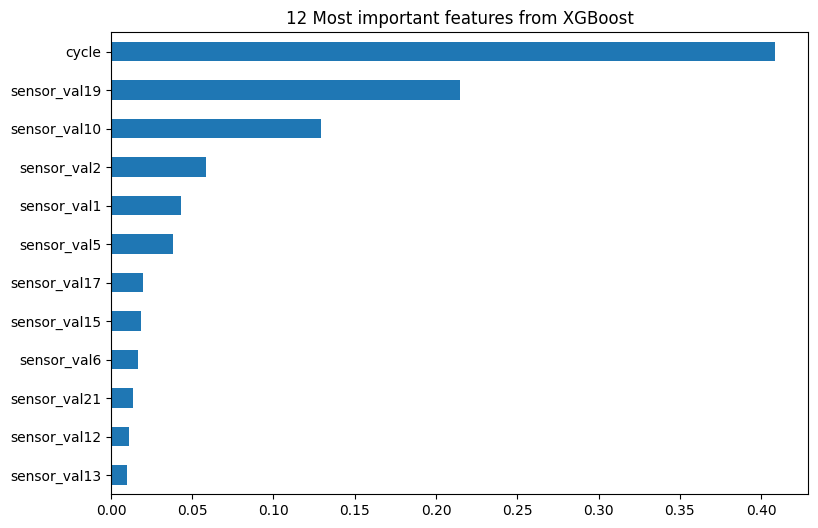

In [39]:
feature_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 6))
feature_importance.sort_values().plot(kind='barh')
plt.title("12 Most important features from XGBoost")
plt.show()

# 1.2 Prediction for dataset 2

The second dataset is loaded.

In [40]:
data_schedule = pd.read_csv("DataSchedule.csv")

The same features are dropped. This ensures that the model uses the same variables during training.

In [41]:
data_schedule = data_schedule.drop(columns=low_std_features)
data_schedule = data_schedule.drop(columns=['sensor_val3'])

data_schedule.head()

,engine_id,cycle,sensor_val1,sensor_val2,sensor_val4,sensor_val5,sensor_val6,sensor_val9,sensor_val10,sensor_val12,sensor_val13,sensor_val15,sensor_val17,sensor_val19,sensor_val21
0,1,1,9050.17,521.72,1585.29,553.90,38.86,2388.03,1398.21,392,2388.04,643.02,8.4052,47.20,23.3735
1,1,2,9054.42,522.16,1588.45,554.85,39.02,2388.06,1395.42,393,2388.01,641.71,8.3803,47.50,23.3916
2,1,3,9056.96,521.97,1586.94,554.11,39.08,2388.03,1401.34,393,2388.05,642.46,8.4441,47.50,23.4166
3,1,4,9045.29,521.38,1584.12,554.07,39.00,2388.05,1406.42,391,2388.03,642.44,8.3917,47.28,23.3737
4,1,5,9044.55,522.15,1587.19,554.16,38.99,2388.03,1401.92,390,2388.01,642.51,8.4031,47.31,23.4130


For each engine in dataset 2, only the last observed row is needed. That row gives the latest information before the RUL has to be predicted, as you want the prediction based on the engine's current condition, not its earlier condition.

In [42]:
latest_schedule_data = data_schedule.sort_values(['engine_id', 'cycle']).groupby('engine_id').tail(1).copy() # sorts by engine and cycle and takes the most recent observation (last row of group)

latest_schedule_data['predicted_RUL'] = (
    xgb_model.predict(latest_schedule_data.drop(columns=['engine_id']))
    .round()
    .astype(int)
    .clip(min=0) # prediction not below 0
)

This results in the following predictions

In [43]:
predictions = latest_schedule_data[['engine_id', 'predicted_RUL']].reset_index(drop=True)
predictions.head(10)

,engine_id,predicted_RUL
0,1,173
1,2,149
2,3,57
3,4,79
4,5,103
5,6,103
6,7,102
7,8,77
8,9,136
9,10,109


### Comparing the predictions with the consultancy predictions
The consultancy predictions are loaded

In [44]:
consultancy = pd.read_csv("RUL_consultancy_predictions_A3.csv", sep=";")

Afterwards both dataframes are merged and a comparison between the two is created.

In [45]:

comparison = predictions.merge(consultancy, left_on='engine_id', right_on='id')
comparison['difference'] = comparison['predicted_RUL'] - comparison['RUL']
comparison['absolute_difference'] = comparison['difference'].abs()

print("Average absolute difference:", round(comparison['absolute_difference'].mean(), 2))
print("The difference with + and - included:", round(comparison['difference'].mean(), 2))

comparison[['engine_id', 'predicted_RUL', 'RUL', 'difference']].head(10)

Average absolute difference: 13.89
The difference with + and - included: 2.55


,engine_id,predicted_RUL,RUL,difference
0,1,173,135,38
1,2,149,125,24
2,3,57,63,-6
3,4,79,100,-21
4,5,103,103,0
5,6,103,122,-19
6,7,102,106,-4
7,8,77,90,-13
8,9,136,121,15
9,10,109,67,42


Below a figure shows the comparison between the prediction per engine. Above zero means our model predicts a higher RUL. When it is below zero, the consultancy predicts a higher RUL.

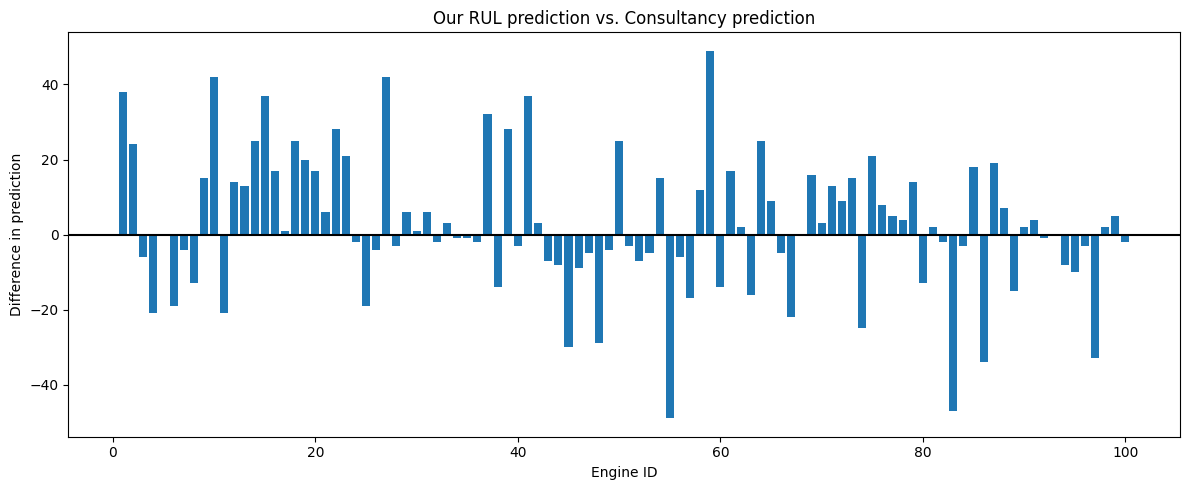

In [46]:
plt.figure(figsize=(12, 5))
plt.bar(comparison['engine_id'], comparison['difference'])
plt.axhline(0,color='black')
plt.title("Our RUL prediction vs. Consultancy prediction")
plt.xlabel("Engine ID")
plt.ylabel("Difference in prediction")
plt.tight_layout()
plt.show()